In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df_train = pd.read_csv("train.csv")
# df_test = pd.read_csv("test.csv")

In [4]:
df_train.head()

,Hour,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Month_Num,Date_Day,is_weekend,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Rented Bike Count
0,0.833333,0.639594,0.59375,-0.227684,0.166197,-0.010753,0.0,0.0,0.333333,0.333333,0.0,0.0,1.0,0.0,0.0,1828
1,-0.166667,-0.502538,-0.62500,-0.148918,0.291080,0.881720,0.0,0.0,-0.500000,0.333333,0.0,1.0,0.0,0.0,0.0,374
2,0.833333,0.162437,-0.90625,-0.395753,0.287324,-0.010753,0.0,0.0,-0.333333,0.333333,1.0,1.0,0.0,0.0,0.0,1292
3,-0.166667,-0.304569,-0.12500,-0.581656,-0.733333,1.064516,0.0,0.0,0.833333,0.200000,0.0,0.0,0.0,0.0,0.0,651
4,0.583333,0.477157,-0.68750,0.205842,-0.916432,0.225806,0.0,0.0,-0.333333,0.266667,0.0,1.0,0.0,0.0,0.0,1578


In [33]:
X = df_train.drop("Rented Bike Count", axis=1)
y = df_train["Rented Bike Count"]

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [15]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
y_pred = lr.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))

323.31803201684005
189052.85815297262
RMSE:  434.80209078725994


In [21]:
print(lr.coef_, end="\n\n")
print(lr.intercept_,end="\n\n")

X_train.columns

[ 335.16249864  542.20081562 -279.82388502   29.56895887   -6.56862606
  -89.01390003  -72.65221168   21.80584419   20.00586402  -19.95306995
 -100.93144354 -131.39070359 -141.39836397 -348.16352572  124.35591997]

1027.3623048872203



Index(['Hour', 'Temperature', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Month_Num', 'Date_Day', 'is_weekend',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday'],
      dtype='str')

In [22]:
pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
1,Temperature,542.200816
13,Seasons_Winter,-348.163526
0,Hour,335.162499
2,Humidity(%),-279.823885
12,Seasons_Summer,-141.398364
11,Seasons_Spring,-131.390704
14,Holiday_No Holiday,124.355920
10,is_weekend,-100.931444
5,Solar Radiation (MJ/m2),-89.013900
6,Rainfall(mm),-72.652212


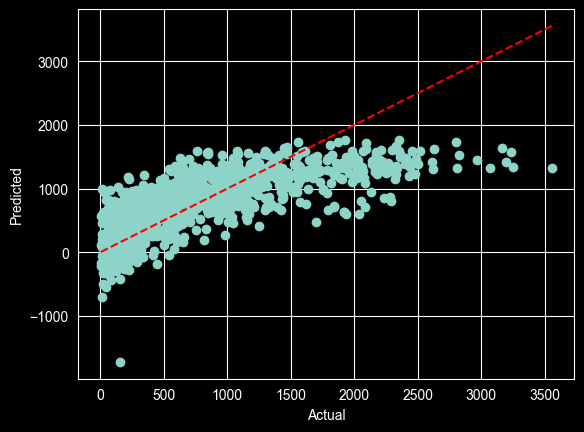

In [24]:
y_pred = lr.predict(X_test)

plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

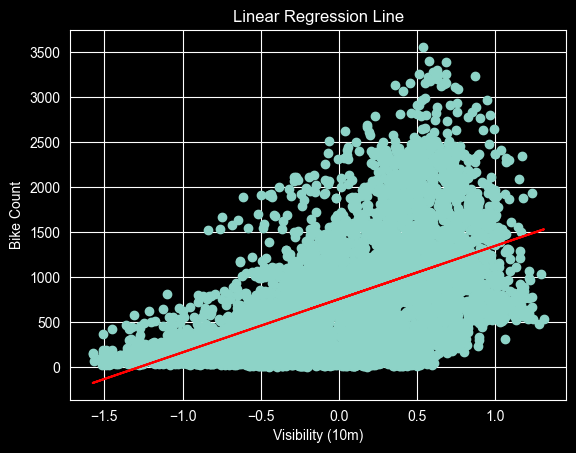

In [30]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

X = df_train[['Temperature']]
y = df_train['Rented Bike Count']

lr = LinearRegression()
lr.fit(X, y)

y_pred = lr.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")

plt.xlabel("Visibility (10m)")
plt.ylabel("Bike Count")
plt.title("Linear Regression Line")
plt.show()

In [26]:
df_train.columns

Index(['Hour', 'Temperature', 'Humidity(%)', 'Wind speed (m/s)',
       'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)',
       'Snowfall (cm)', 'Month_Num', 'Date_Day', 'is_weekend',
       'Seasons_Spring', 'Seasons_Summer', 'Seasons_Winter',
       'Holiday_No Holiday', 'Rented Bike Count'],
      dtype='str')

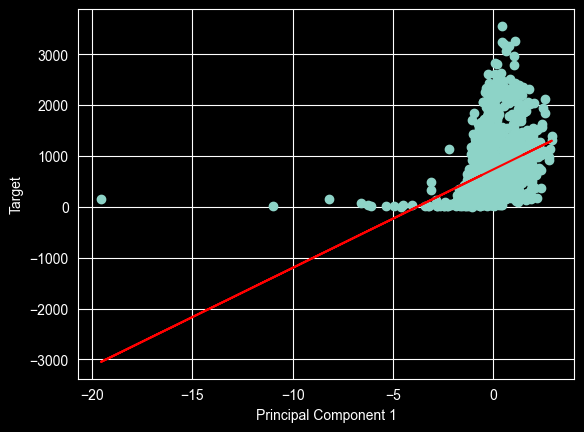

In [29]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

pca = PCA(n_components=1)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_pca, y_train)

y_pred = lr.predict(X_test_pca)

plt.scatter(X_test_pca, y_test)
plt.plot(
    X_test_pca,
    y_pred,
    color='red'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Target")
plt.show()

In [36]:
from sklearn.metrics import r2_score

lr.fit(X_train, y_train)

# Train predictions
y_train_pred = lr.predict(X_train)

# Test predictions
y_test_pred = lr.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train R²:", train_r2)
print("Test R² :", test_r2)

Train R²: 0.5391266566438562
Test R² : 0.5520233130982881
